### 1. Data Exploration
### ● Explore the data, list down the unique values in each feature and find its length.
### ● Perform the statistical analysis and renaming of the columns.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # import libraries

In [3]:
df = pd.read_csv("Employee.csv") # import dataset

In [4]:
df.info() # checking data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  140 non-null    object 
 1   Age      130 non-null    float64
 2   Salary   124 non-null    float64
 3   Place    134 non-null    object 
 4   Country  148 non-null    object 
 5   Gender   148 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 7.1+ KB


In [5]:
for column in df.columns:
    print("Column:",column)
    print("Unique values:",df[column].unique())
    print("Number of unique values:",df[column].nunique())
    print() # finding unique values and their lengths

Column: Company
Unique values: ['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']
Number of unique values: 6

Column: Age
Unique values: [20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]
Number of unique values: 29

Column: Salary
Unique values: [  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]
Number of unique values: 40

Column: Place
Unique values: ['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']
Number of unique values: 11

Column: Country
Unique values: ['India']
Number of unique values: 1

Column: Gender
Unique values: [0 1]
Number of unique values: 2



In [8]:
df.describe() # statistical analysis
df.rename(columns={"Company":"company","Age":"age","Salary":"salary","Place":"place","Country":"country","Gender":"gender"},inplace=True) # renaming the columns
df.head()

,company,age,salary,place,country,gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


### 2. Data Cleaning
### ● Find the missing and inappropriate values, treat them appropriately.
### ● Remove all duplicate rows.
### ● Find the outliers.
### ● Replace the value 0 in age as NaN Treat the null values in all columns using any measures(removing/ replace the values with mean/median/mode) .

In [9]:
df.isnull().sum() # finding missing value

company     8
age        18
salary     24
place      14
country     0
gender      0
dtype: int64

In [10]:
df["age"] = df["age"].replace(0, np.nan) # replace Age 0 with NaN
df["age"].isnull().sum()

np.int64(24)

In [11]:
df["age"] = df["age"].fillna(df["age"].median()) # treating missing values - age, we can use median 
df["salary"] = df["salary"].fillna(df["salary"].median()) # treating missing values - salary

df["place"] = df["place"].fillna(df["place"].mode()[0])  # for place, country and company, we are using mode for the missing values
df["country"] = df["country"].fillna(df["country"].mode()[0])
df["company"] = df["company"].fillna(df["company"].mode()[0])

In [14]:
df.duplicated().sum()
df.drop_duplicates(inplace=True) # removing duplicates

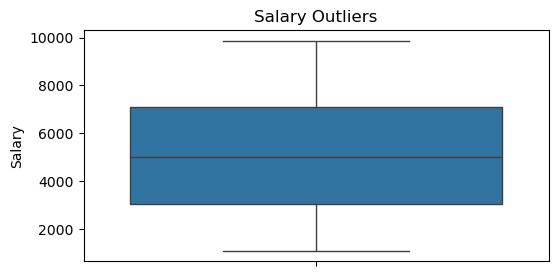

In [16]:
plt.figure(figsize=(6,3)) # finding outliers for salary
sns.boxplot(y=df["salary"])
plt.title("Salary Outliers")
plt.ylabel("Salary")
plt.show()

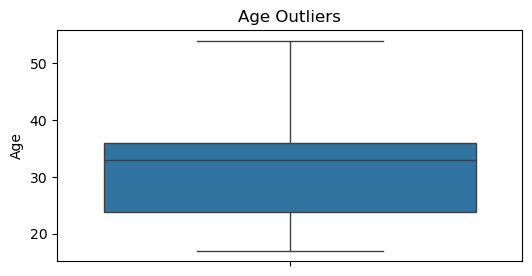

In [18]:
plt.figure(figsize=(6,3)) # finding outliers for age
sns.boxplot(y=df["age"])
plt.title("Age Outliers")
plt.ylabel("Age")
plt.show()

### 3. Data Analysis: (Score : 2)
### ● Filter the data with age >40 and salary<5000 Plot the chart with age and salary Count the number of people from each place and represent it visually

In [19]:
filtered_data = df[(df["age"] > 40) & (df["salary"] < 5000)]
print(filtered_data)

     company   age  salary      place country  gender
21   Infosys  50.0  3184.0      Delhi   India       0
32   Infosys  45.0  4034.0   Calcutta   India       0
39   Infosys  41.0  3000.0     Mumbai   India       0
50   Infosys  41.0  3000.0    Chennai   India       0
57   Infosys  51.0  3184.0  Hyderabad   India       0
68   Infosys  43.0  4034.0     Mumbai   India       0
75   Infosys  44.0  3000.0     Cochin   India       0
86   Infosys  41.0  3000.0      Delhi   India       0
93   Infosys  54.0  3184.0     Mumbai   India       0
104  Infosys  44.0  4034.0      Delhi   India       0
122  Infosys  44.0  3234.0     Mumbai   India       0
129  Infosys  50.0  3184.0   Calcutta   India       0
138      CTS  44.0  3033.0     Cochin   India       0
140  Infosys  44.0  4034.0  Hyderabad   India       0
145  Infosys  44.0  4034.0      Delhi   India       1


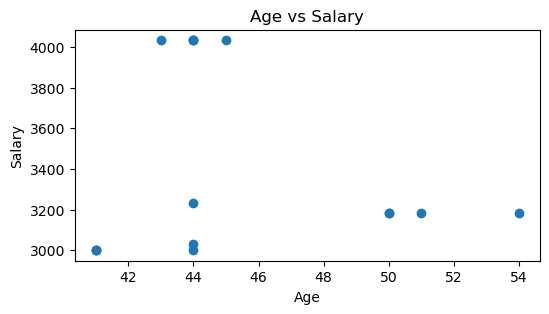

In [20]:
plt.figure(figsize=(6,3))
plt.scatter(filtered_data["age"],filtered_data["salary"])
plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()

### 4. Data Encoding
### ● Convert categorical variables into numerical representations using techniques such as one-hot encoding, label encoding, making them suitable for analysis by machine learning algorithms.

In [22]:
place_count = df["place"].value_counts() # Counting People from each place
print(place_count)

place
Mumbai        48
Calcutta      32
Chennai       14
Delhi         14
Cochin        13
Noida          8
Hyderabad      8
Podicherry     3
Pune           2
Bhopal         1
Nagpur         1
Name: count, dtype: int64


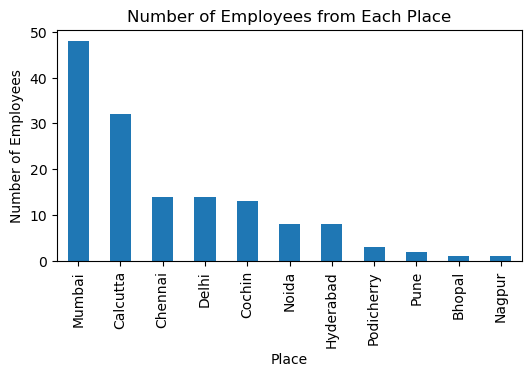

In [23]:
plt.figure(figsize=(6,3)) # creating a chart
place_count.plot(kind="bar")
plt.title("Number of Employees from Each Place")
plt.xlabel("Place")
plt.ylabel("Number of Employees")
plt.show()

In [24]:
df_encoded = pd.get_dummies(df,columns=["company", "place", "country"],drop_first=True) # data encoding- converting company, place, country to numbers
df_encoded.head()

,age,salary,gender,company_Congnizant,company_Infosys,company_Infosys Pvt Lmt,company_TCS,company_Tata Consultancy Services,place_Calcutta,place_Chennai,place_Cochin,place_Delhi,place_Hyderabad,place_Mumbai,place_Nagpur,place_Noida,place_Podicherry,place_Pune
0,20.0,5000.0,0,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False
1,30.0,5000.0,0,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False
2,35.0,2300.0,0,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False
3,40.0,3000.0,0,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False
4,23.0,4000.0,0,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False


### 5. Feature Scaling
### ● After the process of encoding, perform the scaling of the features using standardscaler and minmaxscaler.

In [25]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [26]:
features = df_encoded[["age", "salary"]] # scaling age and salary
standard_scaler = StandardScaler()
standard_scaled = standard_scaler.fit_transform(features)
print(standard_scaled)

[[-1.48467637 -0.10082748]
 [-0.26717411 -0.10082748]
 [ 0.34157702 -1.2437349 ]
 [ 0.95032816 -0.94742557]
 [-1.11942569 -0.52412653]
 [ 0.09807657 -0.10082748]
 [ 0.09807657  0.32247156]
 [-1.11942569  0.74577061]
 [ 0.2198268   1.16906965]
 [ 1.55907929  1.5923687 ]
 [-1.11942569 -0.10082748]
 [ 0.2198268  -1.75635005]
 [ 1.55907929 -0.10082748]
 [-1.72817683 -1.69497168]
 [ 0.95032816 -0.94742557]
 [-1.11942569 -0.94742557]
 [-1.11942569 -0.9347266 ]
 [ 0.2198268  -0.10082748]
 [-1.24117592 -0.10082748]
 [-0.02367366 -0.10082748]
 [ 0.58507748 -0.92837711]
 [ 2.16783042 -0.86953855]
 [-1.36292615 -0.17532811]
 [ 0.09807657  0.25262722]
 [ 0.09807657  0.78132773]
 [-1.11942569  1.56824065]
 [ 0.2198268   1.31510783]
 [ 1.55907929  1.71258563]
 [-1.11942569  1.96317866]
 [ 0.34157702 -1.35633245]
 [ 1.68082952  1.02260818]
 [-1.48467637 -0.97536331]
 [ 1.55907929 -0.50973436]
 [ 0.46332725 -0.08643531]
 [-0.75417501  1.25457606]
 [ 0.34157702  1.60252788]
 [-0.02367366 -0.10082748]
 

In [28]:
minmax_scaler=MinMaxScaler()
minmax_scaled=minmax_scaler.fit_transform(features)
print(minmax_scaled) # MinMaxScaler converts the values to a range between 0 and 1.

[[0.08108108 0.44508934]
 [0.35135135 0.44508934]
 [0.48648649 0.13781723]
 [0.62162162 0.21748037]
 [0.16216216 0.33128485]
 [0.43243243 0.44508934]
 [0.43243243 0.55889382]
 [0.16216216 0.6726983 ]
 [0.45945946 0.78650279]
 [0.75675676 0.90030727]
 [0.16216216 0.44508934]
 [0.45945946 0.        ]
 [0.75675676 0.44508934]
 [0.02702703 0.01650165]
 [0.62162162 0.21748037]
 [0.16216216 0.21748037]
 [0.16216216 0.2208945 ]
 [0.45945946 0.44508934]
 [0.13513514 0.44508934]
 [0.40540541 0.44508934]
 [0.54054054 0.22260157]
 [0.89189189 0.23842039]
 [0.10810811 0.42505975]
 [0.43243243 0.54011608]
 [0.43243243 0.68225788]
 [0.16216216 0.89382042]
 [0.45945946 0.82576534]
 [0.75675676 0.93262775]
 [0.16216216 1.        ]
 [0.48648649 0.10754524]
 [0.78378378 0.74712644]
 [0.08108108 0.20996927]
 [0.75675676 0.33515421]
 [0.51351351 0.44895869]
 [0.24324324 0.80949129]
 [0.48648649 0.90303858]
 [0.40540541 0.44508934]
 [0.48648649 0.44508934]
 [0.45945946 0.13781723]
 [0.64864865 0.21748037]
